In [1]:
# This duplication is for testing XGB without missingness imputation! Woohoo! 
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.model_selection import KFold, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc, classification_report

import time
from datetime import datetime, timedelta

/project/bios26406/conda/ml4h/lib/python3.13/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
training_data_imputed_df = pd.read_csv("training_data_fullset.csv.gz") 

In [3]:
training_data_imputed_df.head()
training_data_imputed_df.shape

(90320, 176)

In [4]:
train_df, val_df = train_test_split(training_data_imputed_df, test_size=0.2, random_state=1)

In [5]:
val_df

,ab_class_is_Fluoroquinolone,ab_class_is_Lincosamide,ab_class_is_Nitroimidazole,ab_class_is_Carbapenem,ab_class_is_Aminoglycoside,ab_class_is_Glycopeptide,ab_class_is_Cephalosporin,ab_class_is_Oxazolidinone,ab_class_is_Macrolide,ab_class_is_Lipopeptide,...,cdiff_7d_flag,cdiff_30d_flag,cdiff_survival_flag,survival_time,cdiff_label_elisa_2d,cdiff_label_elisa_7d,cdiff_label_elisa_30d,cdiff_label_icd9_2d,cdiff_label_icd9_7d,cdiff_label_icd9_30d
24466,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,9.481944,0.0,0.0,0.0,0.0,0.0,0.0
33121,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.576389,0.0,0.0,0.0,0.0,0.0,0.0
8352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,28.506944,0.0,0.0,0.0,0.0,0.0,0.0
58911,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,7.758333,0.0,0.0,0.0,0.0,0.0,0.0
86073,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,4.541667,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7527,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.687500,0.0,0.0,0.0,0.0,0.0,0.0
48785,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,33.770139,0.0,0.0,0.0,0.0,0.0,0.0
11657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,18.937500,0.0,0.0,0.0,0.0,0.0,0.0
4207,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,13.552083,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
X = train_df.drop(['cdiff_2d_flag', 'cdiff_7d_flag', 'cdiff_30d_flag', 'survival_time'], axis=1)


## Sensitivity Analysis 
For 30 days 

In [7]:
y_30 = train_df['cdiff_30d_flag']

In [8]:
param_grid = {
    'n_estimators': [50, 70, 100, 150],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.1, 0.2],
}


neg = (y_30 == 0).sum()
pos = (y_30 == 1).sum()
scale_pos_weight = neg / pos

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=0,
    n_jobs=-1
)

scoring = 'roc_auc'

n_splits = 4
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=skf,
    scoring=scoring,
    verbose=1,
    n_jobs=-1  
)

In [10]:
neg = (y_30 == 0).sum()
pos = (y_30 == 1).sum()
print(f"Negative: {neg}, Positive: {pos}, Ratio: {neg/pos:.2f}")


Negative: 67822, Positive: 4434, Ratio: 15.30


In [11]:
start_time = time.time()
start_datetime = datetime.now()
print(f"Training started at: {start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")

print("Starting GridSearchCV to find optimal parameters...")
grid_search.fit(X, y_30)

print("\nBest parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation {scoring} score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

end_time = time.time()
end_datetime = datetime.now()

duration_seconds = end_time - start_time
duration = timedelta(seconds=duration_seconds)

print(f"Training finished at: {end_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total training time: {duration}")

Training started at: 2025-05-27 16:31:42
Starting GridSearchCV to find optimal parameters...
Fitting 4 folds for each of 32 candidates, totalling 128 fits

Best parameters found:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best cross-validation roc_auc score: 1.0000
Training finished at: 2025-05-27 16:36:50
Total training time: 0:05:08.080782


In [12]:
XGB_model_30 = xgb.XGBClassifier(**grid_search.best_params_, 
                                objective='binary:logistic',
                                eval_metric='auc',
                                random_state=0,
                               n_jobs=-1)
XGB_model_30.fit(X, y_30)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=-1, num_parallel_tree=None, ...)

In [14]:
X_val = val_df.drop(['cdiff_2d_flag', 'cdiff_7d_flag', 'cdiff_30d_flag', 'survival_time'], axis=1)
y_val_30 = val_df['cdiff_30d_flag']

y_val_30.value_counts()

cdiff_30d_flag
0.0    17027
1.0     1037
Name: count, dtype: int64

In [15]:
y_val_pred_30 = XGB_model_30.predict(X_val)
y_val_prob_30 = XGB_model_30.predict_proba(X_val)[:, 1]  

print("\nClassification Report:")
print(classification_report(y_val_30, y_val_pred_30, target_names=['non-cdiff', 'cdiff']))
print(f"ROC AUC: {roc_auc_score(y_true=y_val_30, y_score=y_val_pred_30):.4}")


Classification Report:
              precision    recall  f1-score   support

   non-cdiff       1.00      1.00      1.00     17027
       cdiff       1.00      1.00      1.00      1037

    accuracy                           1.00     18064
   macro avg       1.00      1.00      1.00     18064
weighted avg       1.00      1.00      1.00     18064

ROC AUC: 1.0


<Figure size 1200x800 with 0 Axes>

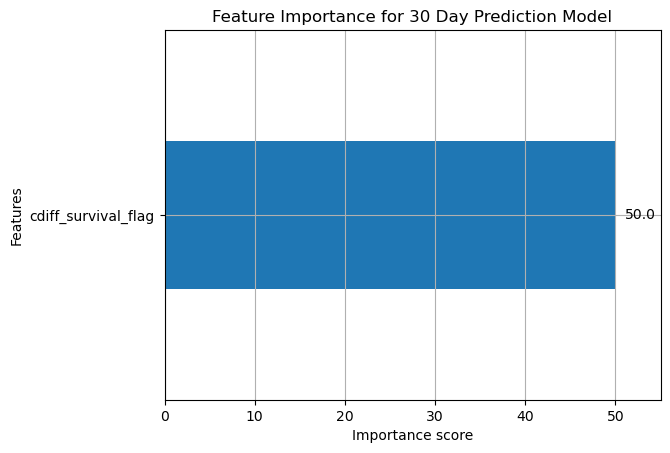

In [16]:
plt.figure(figsize=(12, 8))
xgb.plot_importance(XGB_model_30, max_num_features=30, height=0.8)
plt.title('Feature Importance for 30 Day Prediction Model')
plt.show()

In [17]:
XGB_model_30.save_model('30d_best_model.json')

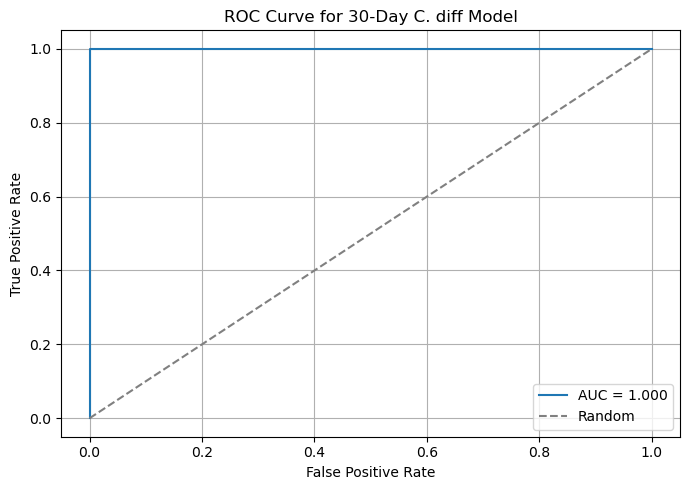

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Ground truth (30-day flag)
y_val_30 = val_df["cdiff_30d_flag"]

# Predicted probabilities from your model (positive class only)
y_val_prob_30 = XGB_model_30.predict_proba(X_val)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val_30, y_val_prob_30)
auc_score = roc_auc_score(y_val_30, y_val_prob_30)

# Plot
plt.figure(figsize=(7, 5))
plt.step(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for 30-Day C. diff Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


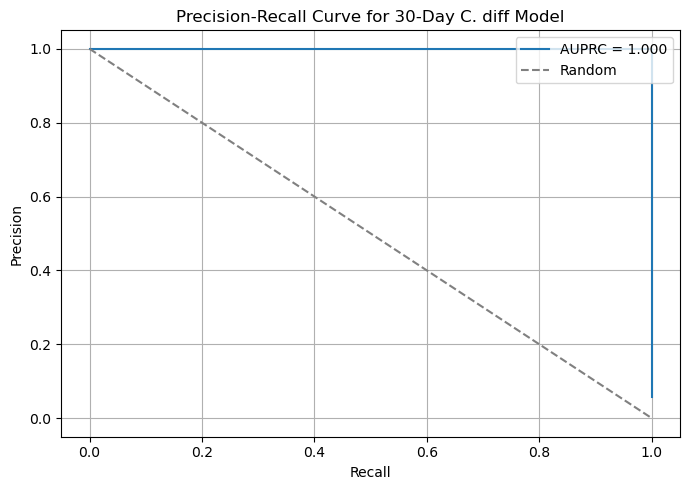

In [19]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Ground truth labels
y_val_30 = val_df["cdiff_30d_flag"]

# Predicted probabilities (positive class)
y_val_prob_30 = XGB_model_30.predict_proba(X_val)[:, 1]

# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_val_30, y_val_prob_30)

# Compute area under the precision-recall curve (AUPRC)
auprc_score = average_precision_score(y_val_30, y_val_prob_30)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AUPRC = {auprc_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0, 1], [1, 0], linestyle='--', color='gray', label="Random")
plt.title("Precision-Recall Curve for 30-Day C. diff Model")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()



For 7 days  

In [20]:
y_7 = train_df['cdiff_7d_flag']

In [21]:
param_grid = {
    'n_estimators': [50, 70, 100, 150],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.1, 0.2],
}


neg = (y_7 == 0).sum()
pos = (y_7 == 1).sum()
scale_pos_weight = neg / pos

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=0,
    n_jobs=-1
)

scoring = 'roc_auc'

n_splits = 4
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=skf,
    scoring=scoring,
    verbose=1,
    n_jobs=-1  
)

In [22]:
neg = (y_7 == 0).sum()
pos = (y_7 == 1).sum()
print(f"Negative: {neg}, Positive: {pos}, Ratio: {neg/pos:.2f}")


Negative: 70409, Positive: 1847, Ratio: 38.12


In [ ]:
start_time = time.time()
start_datetime = datetime.now()
print(f"Training started at: {start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")

print("Starting GridSearchCV to find optimal parameters...")
grid_search.fit(X, y_7)

print("\nBest parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation {scoring} score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

end_time = time.time()
end_datetime = datetime.now()

duration_seconds = end_time - start_time
duration = timedelta(seconds=duration_seconds)

print(f"Training finished at: {end_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total training time: {duration}")

Training started at: 2025-05-27 16:37:38
Starting GridSearchCV to find optimal parameters...
Fitting 4 folds for each of 32 candidates, totalling 128 fits


In [ ]:
XGB_model_7 = xgb.XGBClassifier(**grid_search.best_params_, 
                                objective='binary:logistic',
                                eval_metric='auc',
                                random_state=0,
                               n_jobs=-1)
XGB_model_7.fit(X, y_7)

In [ ]:
X_val = val_df.drop(['cdiff_2d_flag', 'cdiff_7d_flag', 'cdiff_30d_flag', 'survival_time'], axis=1)
y_val_7 = val_df['cdiff_7d_flag']

y_val_7.value_counts()

In [ ]:
y_val_pred_7 = XGB_model_7.predict(X_val)
y_val_prob_7 = XGB_model_7.predict_proba(X_val)[:, 1]  

print("\nClassification Report:")
print(classification_report(y_val_7, y_val_pred_7, target_names=['non-cdiff', 'cdiff']))
print(f"ROC AUC: {roc_auc_score(y_true=y_val_7, y_score=y_val_pred_7):.4}")

In [ ]:
XGB_model_7.save_model('7d_best_model.json')

In [ ]:
plt.figure(figsize=(12, 8))
xgb.plot_importance(XGB_model_7, max_num_features=30, height=0.8)
plt.title('Feature Importance for 7 Day Prediction Model') 
plt.show()

In [ ]:
XGB_model.save_model('7d_best_model.json')

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Ground truth (30-day flag)
y_val_7 = val_df["cdiff_7d_flag"]

# Predicted probabilities from your model (positive class only)
y_val_prob_7 = XGB_model_7.predict_proba(X_val)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val_7, y_val_prob_7)
auc_score = roc_auc_score(y_val_7, y_val_prob_7)

# Plot
plt.figure(figsize=(7, 5))
plt.step(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for 7-Day C. diff Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Ground truth labels
y_val_7 = val_df["cdiff_7d_flag"]

# Predicted probabilities (positive class)
y_val_prob_7 = XGB_model_7.predict_proba(X_val)[:, 1]

# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_val_7, y_val_prob_7)

# Compute area under the precision-recall curve (AUPRC)
auprc_score = average_precision_score(y_val_7, y_val_prob_7)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AUPRC = {auprc_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0, 1], [1, 0], linestyle='--', color='gray', label="Random")
plt.title("Precision-Recall Curve for 7-Day C. diff Model")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


For 2 days  

In [ ]:
y_2 = train_df['cdiff_2d_flag']

In [ ]:
param_grid = {
    'n_estimators': [50, 70, 100, 150],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.1, 0.2],
}


neg = (y_2 == 0).sum()
pos = (y_2 == 1).sum()
scale_pos_weight = neg / pos

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=0,
    n_jobs=-1
)

scoring = 'roc_auc'

n_splits = 4
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=skf,
    scoring=scoring,
    verbose=1,
    n_jobs=-1  
)

In [ ]:
neg = (y_2 == 0).sum()
pos = (y_2 == 1).sum()
print(f"Negative: {neg}, Positive: {pos}, Ratio: {neg/pos:.2f}")


In [ ]:
start_time = time.time()
start_datetime = datetime.now()
print(f"Training started at: {start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")

print("Starting GridSearchCV to find optimal parameters...")
grid_search.fit(X, y_2)

print("\nBest parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation {scoring} score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

end_time = time.time()
end_datetime = datetime.now()

duration_seconds = end_time - start_time
duration = timedelta(seconds=duration_seconds)

print(f"Training finished at: {end_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total training time: {duration}")

In [ ]:
XGB_model_2 = xgb.XGBClassifier(**grid_search.best_params_, 
                                objective='binary:logistic',
                                eval_metric='auc',
                                random_state=0,
                               n_jobs=-1)
XGB_model_2.fit(X, y_2)

In [ ]:
X_val = val_df.drop(['cdiff_2d_flag', 'cdiff_7d_flag', 'cdiff_30d_flag', 'survival_time'], axis=1)
y_val_2 = val_df['cdiff_2d_flag']

y_val_2.value_counts()

In [ ]:
y_val_pred_2 = XGB_model_2.predict(X_val)
y_val_prob_2 = XGB_model_2.predict_proba(X_val)[:, 1]  

print("\nClassification Report:")
print(classification_report(y_val_2, y_val_pred_2, target_names=['non-cdiff', 'cdiff']))
print(f"ROC AUC: {roc_auc_score(y_true=y_val_2, y_score=y_val_pred_2):.4}")

In [ ]:
plt.figure(figsize=(12, 8))
xgb.plot_importance(XGB_model_2, max_num_features=30, height=0.8)
plt.title('Feature Importance for 2 Day Prediction Model') 
plt.show()

In [ ]:
XGB_model_2.save_model('2d_best_model.json')

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Ground truth (30-day flag)
y_val_2 = val_df["cdiff_2d_flag"]

# Predicted probabilities from your model (positive class only)
y_val_prob_2 = XGB_model_2.predict_proba(X_val)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val_2, y_val_prob_2)
auc_score = roc_auc_score(y_val_2, y_val_prob_2)

# Plot
plt.figure(figsize=(7, 5))
plt.step(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for 2-Day C. diff Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Ground truth labels
y_val_2 = val_df["cdiff_2d_flag"]

# Predicted probabilities (positive class)
y_val_prob_2 = XGB_model_2.predict_proba(X_val)[:, 1]

# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_val_2, y_val_prob_2)

# Compute area under the precision-recall curve (AUPRC)
auprc_score = average_precision_score(y_val_2, y_val_prob_2)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AUPRC = {auprc_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0, 1], [1, 0], linestyle='--', color='gray', label="Random")
plt.title("Precision-Recall Curve for 7-Day C. diff Model")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
def run_confidence_validation(label_col, model_name):
    y_train = train_df[label_col]
    y_val = val_df[label_col]

    print(f"\n===== Running model for: {label_col} =====")
    print(f"Class balance: {y_train.value_counts().to_dict()}")

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    param_grid = {
        'n_estimators': [100, 150],
        'max_depth': [5, 7],
        'learning_rate': [0.1, 0.2],
    }

    xgb_clf = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        scale_pos_weight=scale_pos_weight,
        random_state=0,
        n_jobs=-1
    )

    skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=0)
    grid_search = GridSearchCV(
        estimator=xgb_clf,
        param_grid=param_grid,
        cv=skf,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )

    start = time.time()
    grid_search.fit(X, y_train)  # X is from your earlier consistent split
    best_model = grid_search.best_estimator_
    best_model.fit(X, y_train)

    print(f"Best params: {grid_search.best_params_}")
    print(f"Training time: {timedelta(seconds=time.time() - start)}")

    y_prob = best_model.predict_proba(X_val)[:, 1]
    y_pred = best_model.predict(X_val)

    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))
    print(f"ROC AUC: {roc_auc_score(y_val, y_prob):.4f}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_val, y_prob):.3f}")
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR Curve
    precision, recall, _ = precision_recall_curve(y_val, y_prob)
    prc_auc = average_precision_score(y_val, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {prc_auc:.3f}")
    plt.plot([0, 1], [1, 0], linestyle='--', color='gray')
    plt.title(f"PR Curve - {model_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    best_model.save_model(f"{model_name}.json")

# Run these using the SAME X and X_val as above
run_confidence_validation("cdiff_label_elisa_timewindow", "elisa_timewindow_model")
run_confidence_validation("cdiff_label_icd9_timewindow", "icd9_timewindow_model")